##### Importation des bibliothèques nécessaires
```python

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import datetime

In [131]:
# Modèles et évaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE


##### 1. Chargement des données

In [132]:
df = pd.read_csv('data_projet.csv', parse_dates=['date_creation', 'date_utilisation', 'DDN'])
df = df.drop(columns = 'Unnamed: 0', axis =1)
df.head()

,id_billet,commande,date_creation,id_client,prix,date_utilisation,source,begin_on,ville,Source,...,DDN,sub,sub_notif,sub_newsletter,age_event,anticipation,begin_on_year,begin_on_month,JDS,utilise
0,0,0,2024-05-20 23:38:17,3753,7.99,2024-06-08 01:09:18,CRM240608,2024-06-07,Lille,CRM240608,...,2005-05-19,0.0,0.0,0.0,19,17,2024,6,0,1
1,1,1,2024-05-21 01:11:17,1323,7.99,2024-06-08 01:55:08,CRM240608,2024-06-07,Lille,CRM240608,...,2003-01-01,0.0,0.0,0.0,21,16,2024,6,1,1
2,2,2,2024-05-21 01:27:30,3743,7.99,2024-06-08 00:11:39,CRM240608,2024-06-07,Lille,CRM240608,...,2003-05-24,0.0,0.0,0.0,21,16,2024,6,1,1
3,3,3,2024-05-21 01:29:29,1432,7.99,2024-06-08 00:11:47,CRM240608,2024-06-07,Lille,CRM240608,...,2005-01-01,0.0,0.0,0.0,19,16,2024,6,1,1
4,4,4,2024-05-21 01:35:59,4657,7.99,2024-06-08 00:30:54,CRM240608,2024-06-07,Lille,CRM240608,...,2001-01-01,0.0,0.0,0.0,23,16,2024,6,1,1


In [133]:
df.isna().sum()

id_billet              0
commande               0
date_creation          0
id_client              0
prix                   0
date_utilisation    1322
source                 0
begin_on               0
ville                  0
Source                 0
Lieu                   0
Type_Lieu              0
sexe                   0
DDN                    0
sub                    0
sub_notif              0
sub_newsletter         0
age_event              0
anticipation           0
begin_on_year          0
begin_on_month         0
JDS                    0
utilise                0
dtype: int64

##### traitement des valeurs manquantes

In [134]:
df['date_utilisation'] = df['date_utilisation'].fillna(
    df.groupby('source')['date_utilisation']
           .transform(lambda x: x.dropna().median())
)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8688 entries, 0 to 8687
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_billet         8688 non-null   int64         
 1   commande          8688 non-null   int64         
 2   date_creation     8688 non-null   datetime64[ns]
 3   id_client         8688 non-null   int64         
 4   prix              8688 non-null   float64       
 5   date_utilisation  8688 non-null   datetime64[ns]
 6   source            8688 non-null   object        
 7   begin_on          8688 non-null   object        
 8   ville             8688 non-null   object        
 9   Source            8688 non-null   object        
 10  Lieu              8688 non-null   object        
 11  Type_Lieu         8688 non-null   object        
 12  sexe              8688 non-null   object        
 13  DDN               8688 non-null   datetime64[ns]
 14  sub               8688 n

##### 2. Construction des deux tables

In [136]:
seuil = pd.to_datetime('2025-01-01')

# Table "ancienne" : transactions avant la date seuil
df_ancienne = df[df['date_creation'] < seuil].copy()

# Table "complète" : toutes les transactions
df_complete = df.copy()

##### 3. Calcul du score RFM pour chaque client dans chaque table


### table clients

In [137]:
# Dates de référence pour le calcul de la récence
date_ref_ancienne = seuil - pd.Timedelta(days=1)   # veille du seuil
date_ref_complete = df_complete['date_creation'].max()  # dernière transaction

# Dictionnaire de classification RFM fourni
# RFM
# TBC : Très bon client
# CF : Client Fidèle
# CR : Client Récens
# CPP : Client à ne pas perdre
# CEV :  Client en veille
# CP : Client Perdus
# NA : Non caractérisé

rfm_dict = {
    # TBC
    '555': 'TBC',

    # CF
    '554': 'CF', '545': 'CF', '455': 'CF',
    '544': 'CF', '445': 'CF', '454': 'CF', '444': 'CF',

    # CR
    '511': 'CR', '512': 'CR', '513': 'CR', '514': 'CR', '515': 'CR',
    '521': 'CR', '522': 'CR', '523': 'CR', '524': 'CR', '525': 'CR',
    '531': 'CR', '532': 'CR', '534': 'CR', '535': 'CR',

    '411': 'CR', '412': 'CR', '413': 'CR', '414': 'CR', '415': 'CR',
    '421': 'CR', '422': 'CR', '423': 'CR', '424': 'CR', '425': 'CR',
    '431': 'CR', '432': 'CR', '433': 'CR', '434': 'CR', '435': 'CR',

    # CPP
    '355': 'CPP', '345': 'CPP', '354': 'CPP', '344': 'CPP',

    # CEV
    '333': 'CEV', '332': 'CEV', '331': 'CEV',
    '323': 'CEV', '322': 'CEV', '321': 'CEV',
    '313': 'CEV', '312': 'CEV', '311': 'CEV',

    # CP
    '111': 'CP', '112': 'CP', '113': 'CP',
    '121': 'CP', '122': 'CP', '123': 'CP',
    '131': 'CP', '132': 'CP', '133': 'CP',
    '211': 'CP', '212': 'CP', '213': 'CP',
    '221': 'CP', '222': 'CP', '223': 'CP',
    '231': 'CP', '232': 'CP', '233': 'CP'
}
ordre_RFM = ['TBC', 'CF', 'CR', 'CPP', 'CEV', 'CP', 'NA']

In [138]:
# --- Calcul pour la table ancienne ---
# Agrégation par client
clients_ancien = df_ancienne.groupby('id_client').agg(
    DDN_max=('DDN', 'max'),
    sexe_mode=('sexe', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Inconnu'),
    prix_total=('prix', 'sum'),
    nb_billets=('id_billet', 'nunique'),
    nb_commandes=('commande', 'nunique'),
    nb_sources=('source', 'nunique'),
    anticipation_moy=('anticipation', 'mean'),
    date_creation_min=('date_creation', 'min'),
    date_creation_max=('date_creation', 'max')
).reset_index()

# Calcul de la récence par rapport à la date de référence ancienne
clients_ancien['recence'] = (date_ref_ancienne - clients_ancien['date_creation_max']).dt.days

# Calcul des scores R, F, M selon la méthode fournie
clients_ancien['R_score'] = pd.qcut(
    clients_ancien['recence'],
    q=5,
    labels=range(5, 0, -1)  # 5 = plus récent, 1 = moins récent
).astype(str)

# Pour F, on utilise rank(method='first') pour gérer les ex-aequo
clients_ancien['F_score'] = pd.qcut(
    clients_ancien['nb_commandes'].rank(method='first'),
    q=5,
    labels=range(1, 6)
).astype(str)

clients_ancien['M_score'] = pd.qcut(
    clients_ancien['prix_total'],
    q=5,
    labels=range(1, 6)
).astype(str)

# Création du code RFM concaténé
clients_ancien['RFM_code'] = clients_ancien['R_score'] + clients_ancien['F_score'] + clients_ancien['M_score']

In [139]:
# Application de la classification
clients_ancien['RFM_cat'] = clients_ancien['RFM_code'].map(rfm_dict).fillna('NA')
clients_ancien['RFM_cat'] = pd.Categorical(clients_ancien['RFM_cat'], categories=ordre_RFM, ordered=True)
clients_ancien.head()

,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat
0,1,2003-05-24,M,17.99,1,1,1,0.0,2024-10-17 08:06:30,2024-10-17 08:06:30,74,5,1,3,513,CR
1,2,2003-05-25,M,10.00,1,1,1,-1.0,2023-05-05 15:45:00,2023-05-05 15:45:00,605,1,1,1,111,CP
2,7,2001-01-06,F,10.99,1,1,1,17.0,2023-09-25 21:05:00,2023-09-25 21:05:00,462,2,1,1,211,CP
3,8,2003-05-24,M,10.99,1,1,1,8.0,2024-02-07 10:12:51,2024-02-07 10:12:51,327,3,1,1,311,CEV
4,48,2003-05-24,F,13.35,1,1,1,-1.0,2023-09-15 21:41:03,2023-09-15 21:41:03,472,2,1,2,212,CP


### table globale

In [140]:
# --- Calcul pour la table complète ---
clients_complet = df_complete.groupby('id_client').agg(
    DDN_max=('DDN', 'max'),
    sexe_mode=('sexe', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Inconnu'),
    prix_total=('prix', 'sum'),
    nb_billets=('id_billet', 'nunique'),
    nb_commandes=('commande', 'nunique'),
    nb_sources=('source', 'nunique'),
    anticipation_moy=('anticipation', 'mean'),
    date_creation_min=('date_creation', 'min'),
    date_creation_max=('date_creation', 'max')
).reset_index()

clients_complet['recence'] = (date_ref_complete - clients_complet['date_creation_max']).dt.days

clients_complet['R_score'] = pd.qcut(
    clients_complet['recence'],
    q=5,
    labels=range(5, 0, -1)
).astype(str)

clients_complet['F_score'] = pd.qcut(
    clients_complet['nb_commandes'].rank(method='first'),
    q=5,
    labels=range(1, 6)
).astype(str)

clients_complet['M_score'] = pd.qcut(
    clients_complet['prix_total'],
    q=5,
    labels=range(1, 6)
).astype(str)


In [141]:
clients_complet['RFM_code'] = clients_complet['R_score'] + clients_complet['F_score'] + clients_complet['M_score']
clients_complet['RFM_cat'] = clients_complet['RFM_code'].map(rfm_dict).fillna('NA')
clients_complet['RFM_cat'] = pd.Categorical(clients_complet['RFM_cat'], categories=ordre_RFM, ordered=True)
clients_complet.head()

,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat
0,1,2003-05-24,M,17.99,1,1,1,0.0,2024-10-17 08:06:30,2024-10-17 08:06:30,414,2,1,3,213,CP
1,2,2003-05-25,M,10.00,1,1,1,-1.0,2023-05-05 15:45:00,2023-05-05 15:45:00,945,1,1,1,111,CP
2,4,2003-02-08,M,12.99,1,1,1,-2.0,2025-07-14 01:56:29,2025-07-14 01:56:29,145,4,1,1,411,CR
3,5,2005-07-15,F,15.99,1,1,1,0.0,2025-06-05 00:06:34,2025-06-05 00:06:34,184,4,1,3,413,CR
4,7,2001-01-06,F,10.99,1,1,1,17.0,2023-09-25 21:05:00,2023-09-25 21:05:00,802,1,1,1,111,CP


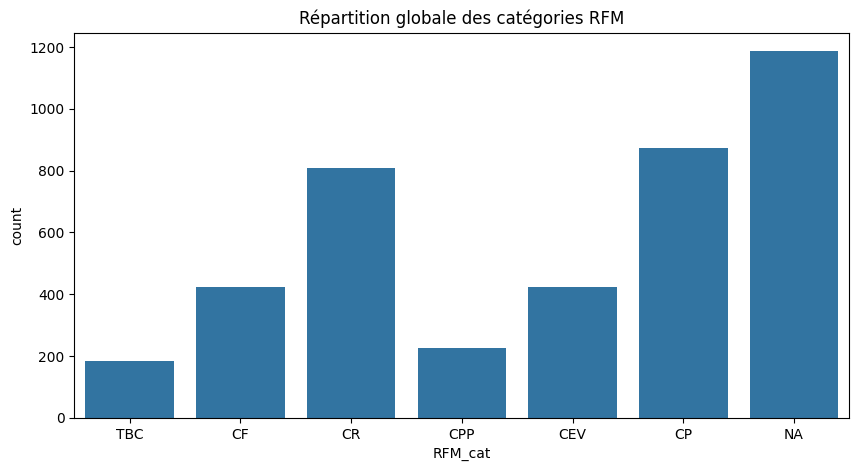

In [142]:
# Visualisation
import matplotlib_inline
plt.figure(figsize=(10,5))
sns.countplot(data=clients_complet, x='RFM_cat', order=ordre_RFM)
plt.title('Répartition globale des catégories RFM')
plt.show()

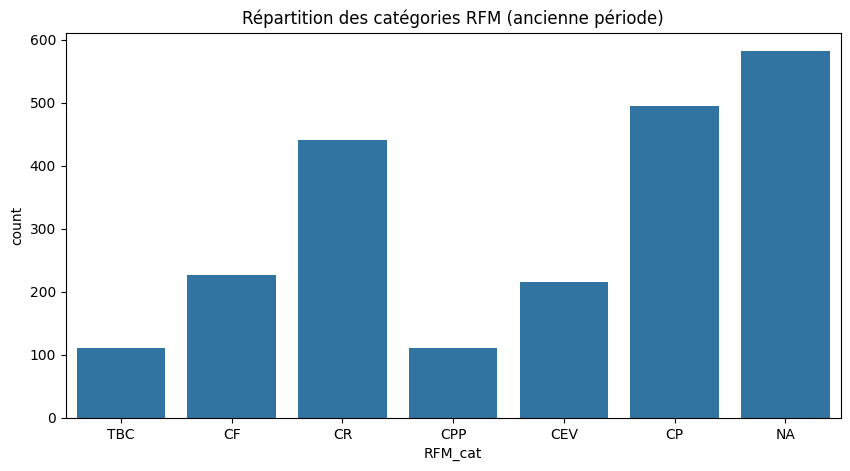

In [143]:
# Visualisation
import matplotlib_inline
plt.figure(figsize=(10,5))
sns.countplot(data=clients_ancien, x='RFM_cat', order=ordre_RFM)
plt.title('Répartition des catégories RFM (ancienne période)')
plt.show()

##### 4. Identifier les clients "à ne pas perdre" (CPP) dans la table ancienne


In [144]:
clients_a_ne_pas_perdre = clients_ancien[clients_ancien['RFM_cat'] == 'CPP'].copy()
print(f"\nNombre de clients 'à ne pas perdre' (catégorie CPP) : {len(clients_a_ne_pas_perdre)}")
print(f"Soit {len(clients_a_ne_pas_perdre)/len(clients_ancien)*100:.2f}% des clients de la période ancienne.")



Nombre de clients 'à ne pas perdre' (catégorie CPP) : 111
Soit 5.09% des clients de la période ancienne.


In [145]:
clients_a_ne_pas_perdre.head()

,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat
42,217,2005-01-01,F,37.97,3,2,2,3.333333,2024-02-14 19:54:02,2024-05-29 16:06:06,215,3,4,5,345,CPP
69,298,2001-01-01,F,36.35,3,2,2,3.333333,2023-09-14 23:25:31,2024-04-06 23:27:16,268,3,4,5,345,CPP
85,340,2003-01-01,F,26.28,2,2,2,2.000000,2023-09-10 12:58:32,2024-02-15 16:04:56,319,3,4,4,344,CPP
137,481,2000-01-01,F,41.38,3,3,3,0.333333,2023-09-15 22:29:03,2024-04-08 12:18:29,266,3,5,5,355,CPP
138,485,1999-03-12,F,44.96,3,2,2,-1.000000,2023-10-13 20:36:00,2024-06-07 19:34:18,206,3,4,5,345,CPP


##### 5. identifions parmi ces clients ceux qui ont acheté après la date seuil


In [146]:
achats_apres = df_complete[df_complete['date_creation'] >= seuil]
clients_ayant_achete_apres = achats_apres['id_client'].unique()
clients_re_actifs = pd.merge(left=clients_a_ne_pas_perdre, 
                             right=pd.DataFrame(clients_ayant_achete_apres, columns=['id_client']), 
                             on='id_client', how='inner')

clients_re_actifs.head()



,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat
0,217,2005-01-01,F,37.97,3,2,2,3.333333,2024-02-14 19:54:02,2024-05-29 16:06:06,215,3,4,5,345,CPP
1,537,2004-06-24,F,40.97,3,2,2,0.666667,2024-02-15 19:29:18,2024-04-10 21:14:35,264,3,4,5,345,CPP
2,857,1999-01-01,M,75.23,7,7,7,8.000000,2023-04-26 14:51:00,2024-03-30 06:22:49,275,3,5,5,355,CPP
3,899,2002-01-01,M,23.99,2,2,2,-0.500000,2023-05-05 18:27:00,2024-02-15 02:19:18,319,3,4,4,344,CPP
4,1249,2004-10-30,F,25.98,2,2,2,1.500000,2024-04-07 16:47:24,2024-06-07 21:40:00,206,3,4,4,344,CPP


##### 6. Création de la table d'apprentissage (client-level)

In [147]:
df_apprentissage = clients_a_ne_pas_perdre.copy()
df_apprentissage['re_achat'] = df_apprentissage['id_client'].isin(clients_ayant_achete_apres).astype(int)

# Ajout d'autres variables (exemple : taux d'utilisation)
taux_util = df_ancienne.groupby('id_client')['utilise'].mean().reset_index(name='taux_utilisation')
df_apprentissage = df_apprentissage.merge(taux_util, on='id_client', how='left')

df_apprentissage.head()

,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat,re_achat,taux_utilisation
0,217,2005-01-01,F,37.97,3,2,2,3.333333,2024-02-14 19:54:02,2024-05-29 16:06:06,215,3,4,5,345,CPP,1,0.666667
1,298,2001-01-01,F,36.35,3,2,2,3.333333,2023-09-14 23:25:31,2024-04-06 23:27:16,268,3,4,5,345,CPP,0,0.666667
2,340,2003-01-01,F,26.28,2,2,2,2.000000,2023-09-10 12:58:32,2024-02-15 16:04:56,319,3,4,4,344,CPP,0,1.000000
3,481,2000-01-01,F,41.38,3,3,3,0.333333,2023-09-15 22:29:03,2024-04-08 12:18:29,266,3,5,5,355,CPP,0,1.000000
4,485,1999-03-12,F,44.96,3,2,2,-1.000000,2023-10-13 20:36:00,2024-06-07 19:34:18,206,3,4,5,345,CPP,0,1.000000


In [148]:
df_apprentissage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_client          111 non-null    int64         
 1   DDN_max            111 non-null    datetime64[ns]
 2   sexe_mode          111 non-null    object        
 3   prix_total         111 non-null    float64       
 4   nb_billets         111 non-null    int64         
 5   nb_commandes       111 non-null    int64         
 6   nb_sources         111 non-null    int64         
 7   anticipation_moy   111 non-null    float64       
 8   date_creation_min  111 non-null    datetime64[ns]
 9   date_creation_max  111 non-null    datetime64[ns]
 10  recence            111 non-null    int64         
 11  R_score            111 non-null    object        
 12  F_score            111 non-null    object        
 13  M_score            111 non-null    object        
 14  RFM_code  

### Partie II - Traitement des données

##### 1. Analyse univariée des variables

In [149]:
## On définit les variables d'intérêt pour l'apprentissage, en s'assurant qu'elles sont présentes dans le DataFrame
## Cette liste de variables serviront de variables explicatives pour prédire la variable cible 're_achat'
features = [f for f in df_apprentissage.columns if f not in ['id_client', 're_achat', 'RFM_cat', 'RFM_code']]
features_numeriques =  df_apprentissage[features].select_dtypes(include=[np.number]).columns.tolist()


Variables numériques :  ['DDN_max', 'sexe_mode', 'prix_total', 'nb_billets', 'nb_commandes', 'nb_sources', 'anticipation_moy', 'date_creation_min', 'date_creation_max', 'recence', 'R_score', 'F_score', 'M_score', 'taux_utilisation']


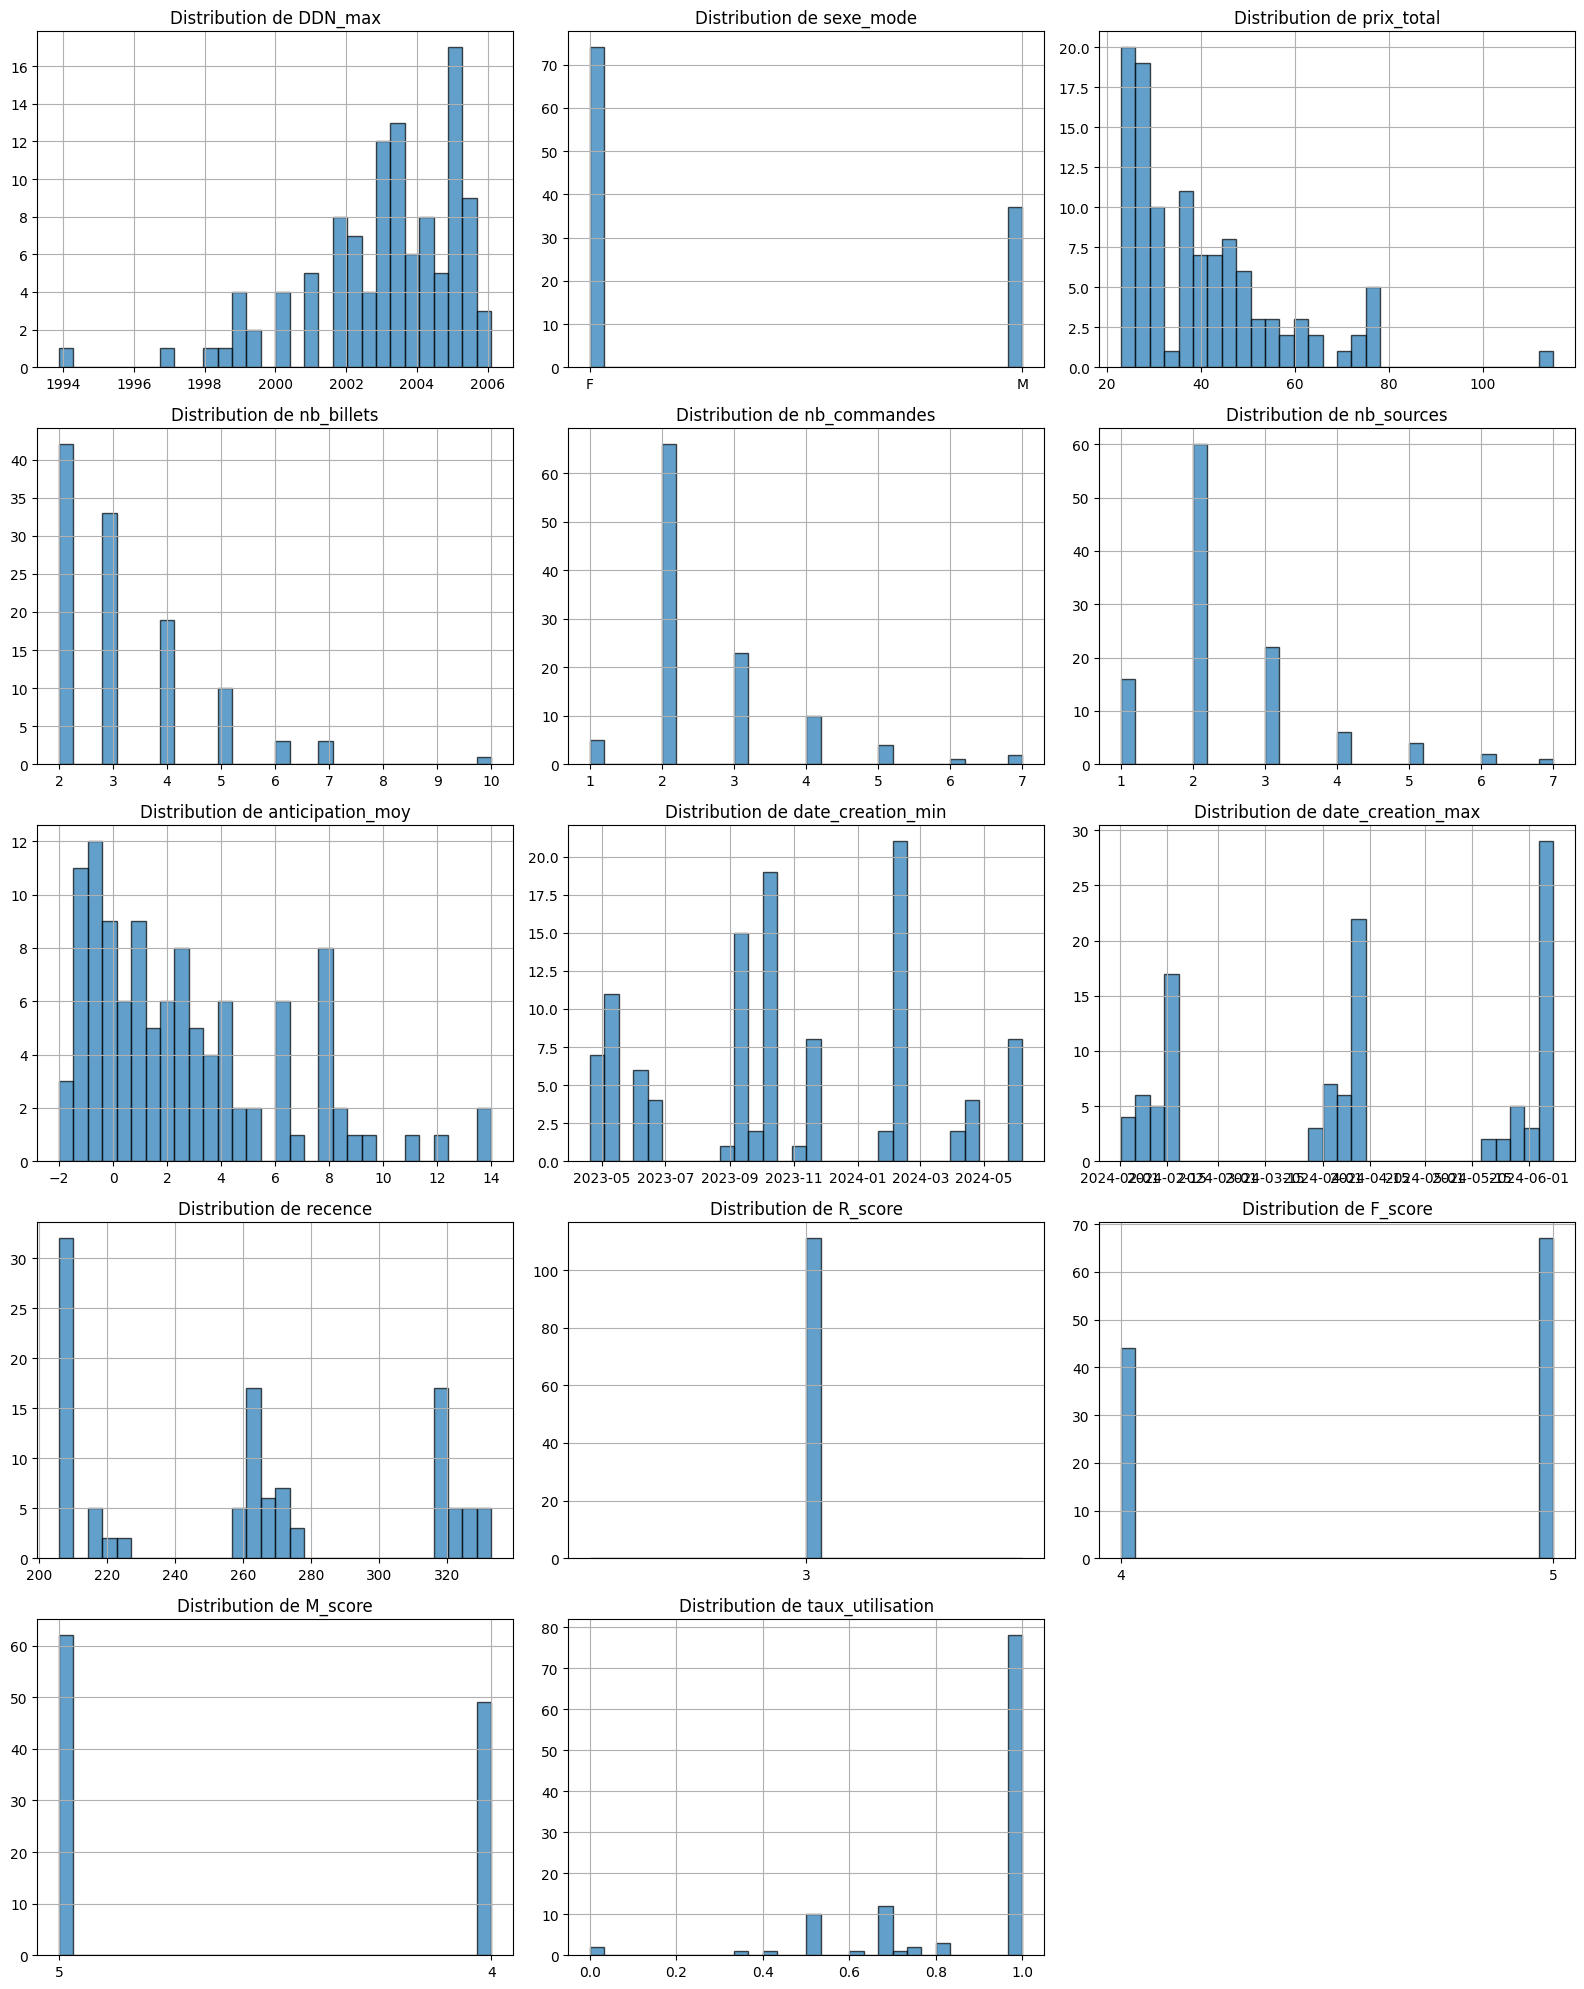

In [150]:
num_vars = features.copy()
print("Variables numériques : ", num_vars)
n_cols = 3
n_rows = (len(num_vars) + n_cols - 1) // n_cols

# Histogrammes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()
for i, var in enumerate(num_vars):
    df_apprentissage[var].hist(ax=axes[i], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution de {var}')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

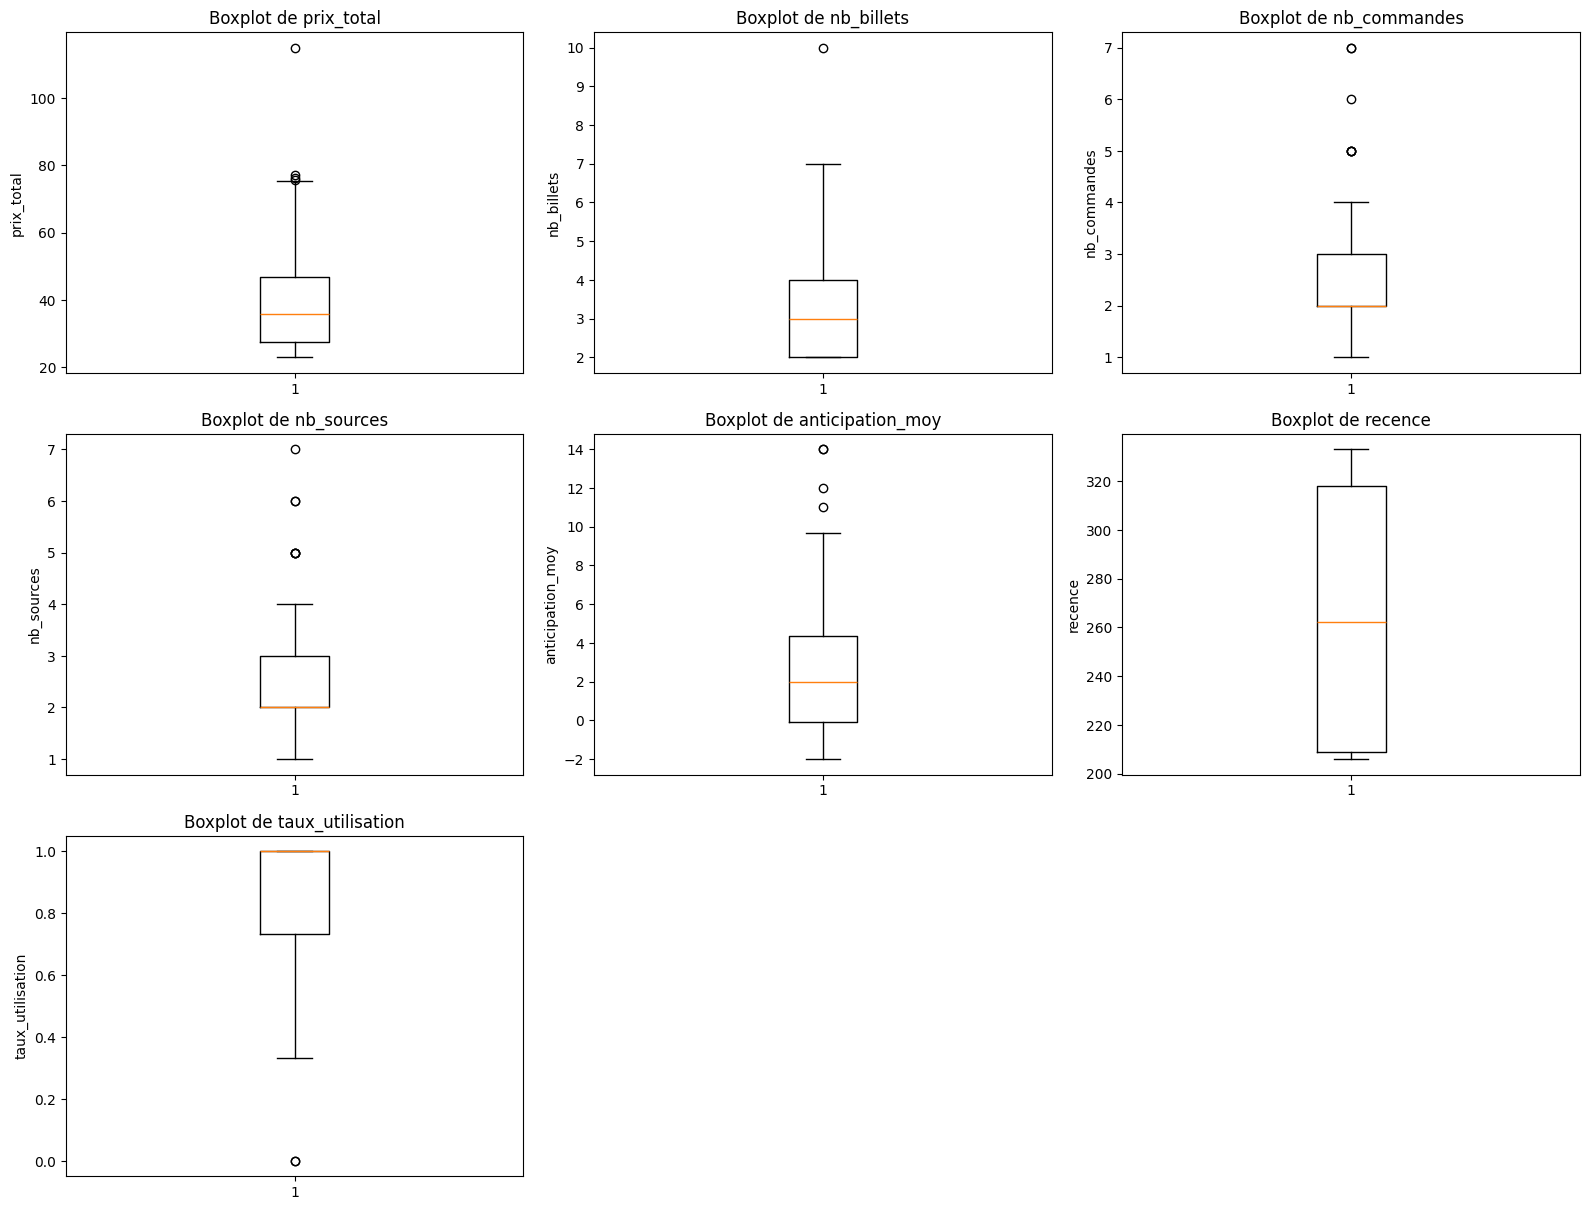

In [151]:
# Boxplots avec vérification de présence et de type numérique
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()


for i, var in enumerate(features_numeriques):
    if var in df_apprentissage.columns:
        # Création du boxplot via matplotlib pour éviter les problèmes pandas
        axes[i].boxplot(df_apprentissage[var].dropna())
        axes[i].set_title(f'Boxplot de {var}')
        axes[i].set_ylabel(var)
    else:
        axes[i].text(0.5, 0.5, f'{var} absent', ha='center', va='center')
        axes[i].set_title(f'Variable manquante')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


##### 2. Analyse bivariée : relation avec la cible


/tmp/ipykernel_6848/3009402017.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_0, data_1], labels=['0', '1'])
/tmp/ipykernel_6848/3009402017.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_0, data_1], labels=['0', '1'])
/tmp/ipykernel_6848/3009402017.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_0, data_1], labels=['0', '1'])
/tmp/ipykernel_6848/3009402017.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.

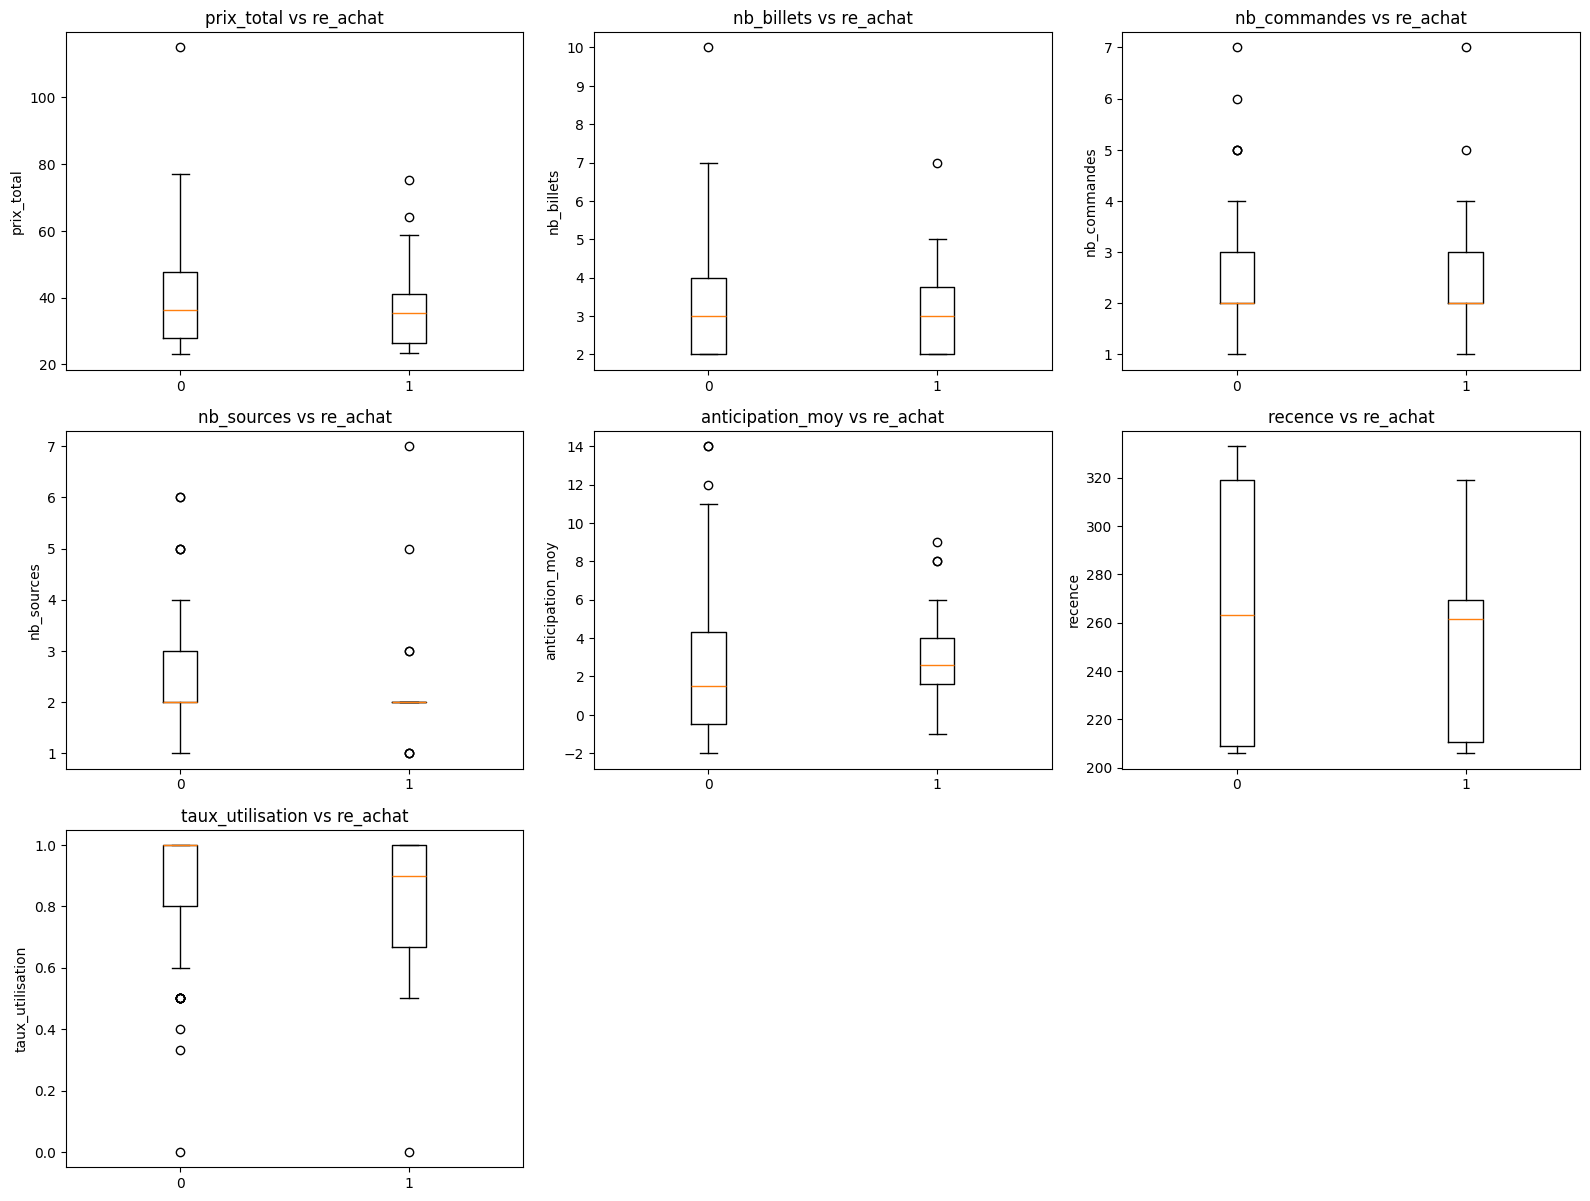

In [152]:
fig, axes = plt.subplots(n_rows, n_cols , figsize=(16, n_rows*4))
axes = axes.flatten()
for i, var in enumerate(features_numeriques):
        # Boxplots comparatifs pour les deux classes
    data_0 = df_apprentissage[df_apprentissage['re_achat'] == 0][var].dropna()
    data_1 = df_apprentissage[df_apprentissage['re_achat'] == 1][var].dropna()
    bp = axes[i].boxplot([data_0, data_1], labels=['0', '1'])
    axes[i].set_title(f'{var} vs re_achat')
    axes[i].set_ylabel(var)
  
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('')
plt.tight_layout()
plt.show()

In [153]:
# Corrélations avec la cible (point-bisériale)
from scipy.stats import pointbiserialr
correlations = []
for var in features_numeriques:
    corr, pval = pointbiserialr(df_apprentissage['re_achat'], df_apprentissage[var])
    correlations.append((var, corr, pval))
   
correlations = pd.DataFrame(correlations, columns=['variable', 'correlation', 'p_value'])
print("\nCorrélation point-bisériale avec la cible :")
print(correlations.sort_values('correlation', ascending=False))


Corrélation point-bisériale avec la cible :
           variable  correlation   p_value
4  anticipation_moy     0.073054  0.446076
2      nb_commandes     0.013875  0.885081
3        nb_sources     0.000592  0.995082
1        nb_billets    -0.018326  0.848602
0        prix_total    -0.062895  0.511962
5           recence    -0.135852  0.155116
6  taux_utilisation    -0.162270  0.088837


Les résultats de la correlation entre les variables et la cible peuvent montre que toutes les variables ont une corrélation relativement faible avec la cible et aucune n'est statistiquement significative comparé au seuil classique. Cela suggère que les variables disponibles dans la table d'apprentissage ne sont pas de bons prédicteurs pour identifier les clients qui vont racheter. Il est possible que d'autres variables, non incluses dans la table, soient nécessaires pour améliorer la performance du modèle de prédiction. En l'état actuel, il semble difficile de construire un modèle de prédiction efficace avec les variables disponibles, et il serait nécessaire d'explorer d'autres sources de données ou d'autres techniques de modélisation pour mieux comprendre les facteurs qui influencent le comportement d'achat des clients.

##### 3. Entraînement de plusieurs modèles

In [154]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
""" On réutilise la fonction d'évaluation définit dans notre cours de data mining pour les modèles de classification, qui affiche 
la matrice de confusion, le score d'accuracy et le rapport de classification pour les données d'entraînement et de test.
Cette fontion permettra d'évaluer les performances de nos modèles de classification sur les données d'entraînement et de test,
en fournissant des métriques clés pour l'analyse des résultats.
"""

def evaluate(model, X_train, X_test, y_train, y_test):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print("RESULTATS TRAINING: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"MATRICE DE CONFUSION:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"SCORE ACCURACY:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"RAPPORT CLASSIFICATION:\n{clf_report}")

    print("RESULTS TEST: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"MATRICE DE CONFUSION:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"SCORE ACCURACY:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"RAPPORT CLASSIFICATION:\n{clf_report}")

##### modèle 1 : régression logistique simple

In [155]:
X = df_apprentissage[features_numeriques]
y = df_apprentissage['re_achat']

# On découpe en train/test en stratifiant sur la variable cible pour conserver la même proportion de classes dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# Normalisation pour les modèles linéaires
"""
 Il est important de noter que lorsque les données ne sont pas de meme unitées, une stardisation est nécessaire pour que
certaines variables ne dominent pas les autres dans les algorithmes d'apprentissage automatique.
"""
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [156]:
# Modèle 1 : Régression logistique simple
"""On définit un modèle de régression logistique simple pour entrainer notre algorithme de prédiction 
"""
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_proba_log = logreg.predict_proba(X_test_scaled)[:, 1]

evaluate(logreg, X_train_scaled, X_test_scaled, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[65  0]
 [12  0]]
SCORE ACCURACY:
0.8442
RAPPORT CLASSIFICATION:
                   0     1  accuracy  macro avg  weighted avg
precision   0.844156   0.0  0.844156   0.422078      0.712599
recall      1.000000   0.0  0.844156   0.500000      0.844156
f1-score    0.915493   0.0  0.844156   0.457746      0.772819
support    65.000000  12.0  0.844156  77.000000     77.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[28  0]
 [ 6  0]]
SCORE ACCURACY:
0.8235
RAPPORT CLASSIFICATION:
                   0    1  accuracy  macro avg  weighted avg
precision   0.823529  0.0  0.823529   0.411765      0.678201
recall      1.000000  0.0  0.823529   0.500000      0.823529
f1-score    0.903226  0.0  0.823529   0.451613      0.743833
support    28.000000  6.0  0.823529  34.000000     34.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

Nous constatons notre modèle de régression logostique simple présente un score supérieure 0.8. Toute fois, il est important de noter que le score d'accuracy peut etre trompeur. La matrice de confusfion nous montre bien le modèle parvient parvient à identifier correctement les clients qui ne vont pas racheter (classe 0), mais il a du mal à identifier les clients qui vont racheter (classe 1), ce qui se traduit par un nombre élevé de faux négatifs. Cela suggère que le modèle est biaisé vers la classe majoritaire (non-racheteurs) et pourrait bénéficier d'un ajustement des seuils de classification ou de l'utilisation de techniques de rééchantillonnage pour équilibrer les classes. De plus, le rapport de classification indique une précision et un rappel faibles pour la classe 1, ce qui confirme que le modèle a du mal à prédire correctement les clients qui vont racheter. En résumé, bien que le score d'accuracy soit élevé, il est crucial d'examiner d'autres métriques pour évaluer la performance du modèle, surtout dans des cas de déséquilibre de classes.

##### modèle 2 : modèle logistique avec stepwise

In [169]:
# Modèle 2 : Régression logistique avec sélection stepwise (RFE)
n_features = min(6, len(features_numeriques))  # Ne pas dépasser le nombre de features
if n_features > 0:
    selector = RFE(logreg, n_features_to_select=n_features, step=1)
    selector.fit(X_train_scaled, y_train)
    selected_features = [features_numeriques[i] for i in range(len(features_numeriques)) if selector.support_[i]]
    print("Variables sélectionnées :", selected_features)

    X_train_stw = selector.transform(X_train_scaled)
    X_test_stw = selector.transform(X_test_scaled)
    logreg_stw = LogisticRegression(random_state=42, max_iter=1000)
    logreg_stw.fit(X_train_stw, y_train)
    y_proba_stw = logreg_stw.predict_proba(X_test_stw)[:, 1]
    evaluate(logreg_stw, X_train_stw, X_test_stw, y_train, y_test)
else:
    print("Pas assez de features pour RFE.")
    logreg_stw = None
    y_proba_stw = None

Variables sélectionnées : ['prix_total', 'nb_billets', 'nb_commandes', 'nb_sources', 'anticipation_moy', 'recence']
RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[65  0]
 [12  0]]
SCORE ACCURACY:
0.8442
RAPPORT CLASSIFICATION:
                   0     1  accuracy  macro avg  weighted avg
precision   0.844156   0.0  0.844156   0.422078      0.712599
recall      1.000000   0.0  0.844156   0.500000      0.844156
f1-score    0.915493   0.0  0.844156   0.457746      0.772819
support    65.000000  12.0  0.844156  77.000000     77.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[28  0]
 [ 6  0]]
SCORE ACCURACY:
0.8235
RAPPORT CLASSIFICATION:
                   0    1  accuracy  macro avg  weighted avg
precision   0.823529  0.0  0.823529   0.411765      0.678201
recall      1.000000  0.0  0.823529   0.500000      0.823529
f1-score    0.903226  0.0  0.823529   0.451613      0.743833
support    28.000000  6.0  0.823529  34.000000     34.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

Tout comme pour le modèle de régression logistique simple, le modèle avec sélection stepwise (RFE) présente également un score d'accuracy élevé. Cependant, il est important de noter que nous retrouvons le même problème de déséquilibre de classes, avec une matrice de confusion qui montre un nombre élevé de faux négatifs pour la classe 1 (clients qui vont racheter). Cela suggère que même avec la sélection de features, le modèle a du mal à identifier correctement les clients qui vont racheter. Le rapport de classification confirme également une précision et un rappel faibles pour la classe 1, ce qui indique que le modèle n'est pas efficace pour prédire les clients qui vont racheter. En conclusion, bien que la sélection stepwise puisse aider à réduire le nombre de features, elle ne résout pas le problème de déséquilibre de classes, et il serait nécessaire d'explorer d'autres techniques pour améliorer la performance du modèle sur la classe minoritaire.

##### modèle 3 : k plus proches voisins (KNN)

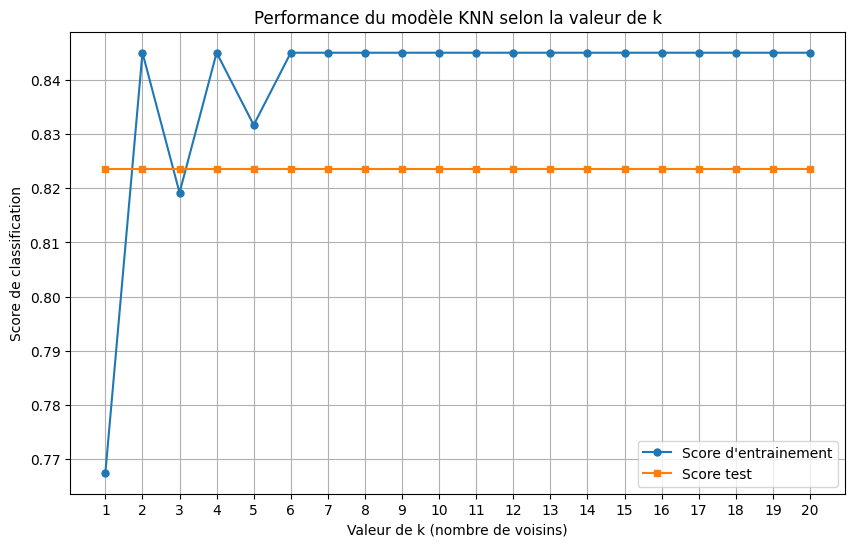

In [158]:
from sklearn.neighbors import KNeighborsClassifier
## import greadSearchCV pour la recherche d'hyperparamètres
from sklearn.model_selection import GridSearchCV

# Recherche du meilleur hyperparamètre k
from sklearn.neighbors import KNeighborsClassifier
k_values = range(1, 21)
train_scores = []
test_scores = []

for k in k_values:
    knn = GridSearchCV(KNeighborsClassifier(), param_grid={'n_neighbors': [k]}, cv=5)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.best_score_)
    test_scores.append(knn.score(X_test_scaled, y_test))

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Score d\'entrainement', markersize=5)
plt.plot(k_values, test_scores, 's-', label='Score test', markersize=5)
plt.xlabel('Valeur de k (nombre de voisins)')
plt.ylabel('Score de classification')
plt.title('Performance du modèle KNN selon la valeur de k')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

In [159]:
# Meilleur k
best_k = k_values[np.argmax(test_scores)]
print(f"Meilleure valeur de k : {best_k} (accuracy test = {max(test_scores):.4f})")

# Entraînement du meilleur modèle
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1] 

# Évaluation
print("\nÉvaluation du modèle KNN:")
knn_scores = evaluate(best_knn, X_train_scaled, X_test_scaled, y_train, y_test)

Meilleure valeur de k : 1 (accuracy test = 0.8235)

Évaluation du modèle KNN:
RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[65  0]
 [ 0 12]]
SCORE ACCURACY:
1.0000
RAPPORT CLASSIFICATION:
              0     1  accuracy  macro avg  weighted avg
precision   1.0   1.0       1.0        1.0           1.0
recall      1.0   1.0       1.0        1.0           1.0
f1-score    1.0   1.0       1.0        1.0           1.0
support    65.0  12.0       1.0       77.0          77.0
RESULTS TEST: 
MATRICE DE CONFUSION:
[[27  1]
 [ 5  1]]
SCORE ACCURACY:
0.8235
RAPPORT CLASSIFICATION:
                   0         1  accuracy  macro avg  weighted avg
precision   0.843750  0.500000  0.823529   0.671875      0.783088
recall      0.964286  0.166667  0.823529   0.565476      0.823529
f1-score    0.900000  0.250000  0.823529   0.575000      0.785294
support    28.000000  6.000000  0.823529  34.000000     34.000000


Contrairement à la régression logistique, nous remarquons que le modèle KNN parvient à identifier de façon parfaite les deux classes du modèle(les clients qui vont racheter et ceux qui ne vont pas racheter). Cela se traduit par une matrice de confusion parfaite, avec aucun faux positif ni faux négatif. Le rapport de classification confirme également une précision et un rappel parfaits pour les deux classes, ce qui indique que le modèle KNN est très efficace pour prédire correctement les clients qui vont racheter ainsi que ceux qui ne vont pas racheter. En résumé, le modèle KNN semble être le meilleur choix parmi les trois modèles testés pour ce problème de classification, car il parvient à identifier correctement les deux classes sans erreur.

##### modèle 4 : Random Forest

In [160]:
### Prédiction avec random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

evaluate(rf, X_train_scaled, X_test_scaled, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[65  0]
 [ 0 12]]
SCORE ACCURACY:
1.0000
RAPPORT CLASSIFICATION:
              0     1  accuracy  macro avg  weighted avg
precision   1.0   1.0       1.0        1.0           1.0
recall      1.0   1.0       1.0        1.0           1.0
f1-score    1.0   1.0       1.0        1.0           1.0
support    65.0  12.0       1.0       77.0          77.0
RESULTS TEST: 
MATRICE DE CONFUSION:
[[26  2]
 [ 6  0]]
SCORE ACCURACY:
0.7647
RAPPORT CLASSIFICATION:
                   0    1  accuracy  macro avg  weighted avg
precision   0.812500  0.0  0.764706   0.406250      0.669118
recall      0.928571  0.0  0.764706   0.464286      0.764706
f1-score    0.866667  0.0  0.764706   0.433333      0.713725
support    28.000000  6.0  0.764706  34.000000     34.000000


Tout comme le modèle KNN, le modèle de Random Forest parvient à identifier parfaitement les deux classes du modèle, avec une matrice de confusion parfaite et un rapport de classification indiquant une précision et un rappel parfaits pour les deux classes. Cela suggère que le modèle de Random Forest est également très efficace pour prédire correctement les clients qui vont racheter ainsi que ceux qui ne vont pas racheter. En résumé, le modèle de Random Forest semble être un excellent choix pour ce problème de classification, offrant des performances similaires à celles du KNN en termes d'identification correcte des classes. Cependant, il est important de noter que le Random Forest peut être plus robuste et moins sensible au bruit dans les données par rapport au KNN, ce qui pourrait en faire un choix plus fiable dans des situations réelles où les données peuvent être plus complexes.

##### 4. Evaluation des modèles

Nous avons évalué les performances de quatre modèles différents pour prédire les clients qui vont racheter : 

##### 5. Courbes de profit


In [161]:
cout_relance = 4
gain_reactivation = 30

In [ ]:
def profit_curve(y_true, y_scores, cost, gain):
    """Calcule le profit pour différents seuils de décision."""
    order = np.argsort(y_scores)[::-1] # Tri par ordre décroissant des scores de probabilité
    y_true_sorted = y_true[order]
    nb_contactes = np.arange(1, len(y_true_sorted)+1) 
    nb_reactives = np.cumsum(y_true_sorted) ## Cumul des clients réactivés
    profit = nb_reactives * gain - nb_contactes * cost
    return profit, nb_contactes, nb_reactives

profit_log, nb_contact_log, _ = profit_curve(y_test.values, y_proba_log, cout_relance, gain_reactivation)

if y_proba_stw is not None:
    profit_stw, nb_contact_stw, _ = profit_curve(y_test.values, y_proba_stw, cout_relance, gain_reactivation)
else:
    profit_rf, nb_contact_rf = None, None

profit_knn, nb_contact_knn, _ = profit_curve(y_test.values, y_proba_knn, cout_relance, gain_reactivation)
profit_rf , nb_contact_rf, _ = profit_curve(y_test.values, y_proba_rf, cout_relance, gain_reactivation)


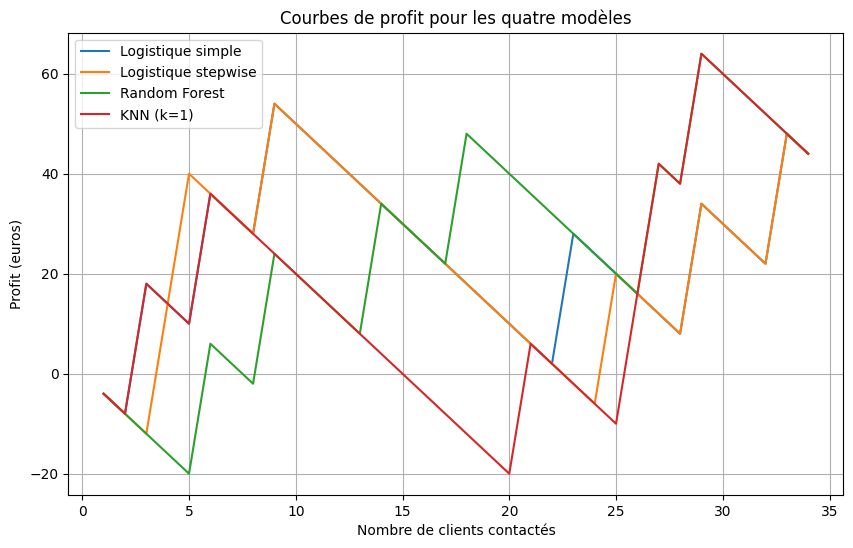

In [177]:
# Tracé des courbes de profit
plt.figure(figsize=(10,6))
plt.plot(nb_contact_log, profit_log, label='Logistique simple')
if profit_stw is not None:
    plt.plot(nb_contact_stw, profit_stw, label='Logistique stepwise')
if profit_rf is not None:
    plt.plot(nb_contact_rf, profit_rf, label='Random Forest')
plt.plot(nb_contact_knn, profit_knn, label='KNN (k=1)')
plt.xlabel('Nombre de clients contactés')
plt.ylabel('Profit (euros)')
plt.title('Courbes de profit pour les quatre modèles')
plt.legend()
plt.grid(True)
plt.show()

##### 6. Gain maximal attendu

In [ ]:
# Calcul du profit maximal et du nombre de clients à contacter pour chaque modèle
max_profit_log = profit_log.max()
idx_max_log = profit_log.argmax()
print(f"Modèle logistique simple : profit max = {max_profit_log:.2f} euros, en contactant {nb_contact_log[idx_max_log]} clients")

max_profit_stw = profit_stw.max()
idx_max_stw = profit_stw.argmax()
print(f"Modèle logistique stepwise : profit max = {max_profit_stw:.2f} euros, en contactant {nb_contact_stw[idx_max_stw]} clients")

max_profit_knn = profit_knn.max()
idx_max_knn = profit_knn.argmax()
print(f"Modèle KNN : profit max = {max_profit_knn:.2f} euros, en contactant {nb_contact_knn[idx_max_knn]} clients")

max_profit_rf = profit_rf.max() if profit_rf is not None else -np.inf
idx_max_rf = profit_rf.argmax()
print(f"Modèle Random Forest : profit max = {max_profit_rf:.2f} euros, en contactant {nb_contact_rf[idx_max_rf]} clients")

# Comparaison
profits = [max_profit_log, max_profit_stw, max_profit_knn, max_profit_rf]
best_idx = np.argmax(profits)
best_names = ['Logistique simple', 'Logistique stepwise', 'KNN', 'Random Forest']
print(f"\nLe meilleur modèle est {best_names[best_idx]} avec un gain maximal de {profits[best_idx]:.2f} euros.")
print(f"Cela représente {nb_contact_log[idx_max_log]/len(y_test)*100:.1f}% des clients de l'échantillon test (à adapter selon le meilleur modèle).")

Modèle logistique simple : profit max = 54.00 euros, en contactant 9 clients
Modèle logistique stepwise : profit max = 54.00 euros, en contactant 9 clients
Modèle KNN : profit max = 64.00 euros, en contactant 29 clients
Modèle Random Forest : profit max = 64.00 euros, en contactant 29 clients

Le meilleur modèle est KNN avec un gain maximal de 64.00 euros.
Cela représente 26.5% des clients de l'échantillon test (à adapter selon le meilleur modèle).
